# Evaluation of supervised models in pediatric brain cancer gene expression data
## Background
Brain cancer is characterised by a variety of genetic changes in cell. Current advances in genotyping and whole genome sequencing data provides a great opportunity to gather large scale genomic data and draw associations with disease status.
Based on previous reports of efficience of certain supervised and unsupervised models in cancer classification based on genomic data, in this project we aimed to compare supervisied models to draw conclusions about efficiency in cancer classification based on gene expression data from a number of genes associated with brain cancer.
The aim of this study is to train supervised models for accurate prediction of brain cancer type in provided sample set and compare their performance - logistic regression vs decision tree.
## Methods
Pediatric brain cancer gene expression data derived from Curated Microarray Database (CuMiDa)4 (Affymetrix Human Genome U133 Plus 2.0 Array).
The dataset includes:
Samples: 130
X = Gene expresison: 54676
y = Normal/Cancer type: 5

Classes: normal=0, ependymoma=1, glioblastoma=2, pilocytic_astrocytoma=3,

medulloblastoma=4

The data has been downloaded at the post-processing stage (csv), it has not been reduced or modified prior to this analysis.

# 1. Import Required Packages
## 1.1 Check and Install Missing Packages
## 1.2 Import Core Libraries
## 1.3 Verify Package Versions

In [1]:
import os
import sys
import subprocess
import pkg_resources

### Check if packages are installed
print(f"\n\n================================\n\033[1mCheck if packages are installed:\033[0m\n================================\n")

### List of required packages
required_packages = [
    'pandas', 'numpy', 'scipy', 'matplotlib', 'statsmodels', 'plotly',
    'scikit-learn', 'xgboost', 'torch', 'umap-learn'
]

### Install missing packages
def install_missing_packages(packages):
    for package in packages:
        try:
            pkg_name = package if package != 'umap-learn' else 'umap'
            dist = pkg_resources.get_distribution(pkg_name)
            print(f"{pkg_name} ({dist.version}) is already installed.")
        except pkg_resources.DistributionNotFound:
            print(f"Installing {package}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
            print(f"{package} installed successfully.")

install_missing_packages(required_packages)

### Import libraries
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import statsmodels.api as sm
import plotly
import plotly.express as px
import plotly.graph_objects as go
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import xgboost as xgb
from xgboost import XGBClassifier
import torch
import umap  

### Print versions
print(f"\n\n=================\n\033[1mVersions:\033[0m\n=================\n")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"scipy: {scipy.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"statsmodels: {sm.__version__}")
print(f"plotly: {plotly.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"xgboost: {xgb.__version__}")
print(f"umap: {umap.__version__}")
print(f"torch: {torch.__version__}")

C:\Users\User\AppData\Local\Temp\ipykernel_25404\1950441932.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources




Check if packages are installed:

pandas (2.3.3) is already installed.
numpy (2.3.5) is already installed.
scipy (1.16.3) is already installed.
matplotlib (3.10.6) is already installed.
statsmodels (0.14.5) is already installed.
plotly (6.3.0) is already installed.
scikit-learn (1.7.2) is already installed.
xgboost (3.2.0) is already installed.
torch (2.10.0) is already installed.
Installing umap-learn...
umap-learn installed successfully.


Versions:

pandas: 2.3.3
numpy: 2.3.5
scipy: 1.16.3
matplotlib: 3.10.6
statsmodels: 0.14.5
plotly: 6.3.0
scikit-learn: 1.7.2
xgboost: 3.2.0
umap: 0.5.11
torch: 2.10.0+cpu


# 2. Load Dataset
## 2.1 Read CSV File
## 2.2 Inspect Initial Data Structure

In [2]:
#  Use raw string to avoid escape character issues
file_path = r"C:\Users\User\Downloads\Brain_GSE50161\Brain_GSE50161.csv"

# Load the dataset
try:
    df = pd.read_csv(file_path, sep=",", header=0)
    print("Dataset loaded successfully!")
    print("First 5 rows of data:")
    print(df.head())
except FileNotFoundError:
    print(f"Error: File not found. Please check if the path is correct! Current path: {file_path}")
    print("Please confirm:")
    print("1. Whether the file actually exists in this path")
    print("2. Whether the file name is correct (note case sensitivity and file extension)")
except Exception as e:
    print(f"Error loading data: {e}")


Dataset loaded successfully!
First 5 rows of data:
   samples        type  1007_s_at   1053_at     117_at    121_at  1255_g_at  \
0      834  ependymoma  12.498150  7.604868   6.880934  9.027128   4.176175   
1      835  ependymoma  13.067436  7.998090   7.209076  9.723322   4.826126   
2      836  ependymoma  13.068179  8.573674   8.647684  9.613002   4.396581   
3      837  ependymoma  12.456040  9.098977   6.628784  8.517677   4.154847   
4      838  ependymoma  12.699958  8.800721  11.556188  9.166309   4.165891   

    1294_at   1316_at   1320_at  ...  AFFX-r2-Ec-bioD-3_at  \
0  7.224920  6.085942  6.835999  ...              9.979005   
1  7.539381  6.250962  8.012549  ...             11.924749   
2  7.813101  6.007746  7.178156  ...             12.154405   
3  8.361843  6.596064  6.347285  ...             11.969072   
4  7.923826  6.212754  6.866387  ...             11.411701   

   AFFX-r2-Ec-bioD-5_at  AFFX-r2-P1-cre-3_at  AFFX-r2-P1-cre-5_at  \
0              9.926470         

## 2.3 Map Categorical Labels to Numerical Values
## 2.4 Check for Missing Values
## 2.5 Split Features (X) and Target (y)

In [3]:
### Assign classes to cancer types
mapping = {
    'normal': 0,
    'ependymoma': 1,
    'glioblastoma': 2,
    'pilocytic_astrocytoma': 3,
    'medulloblastoma': 4
}

### Map numerical values to string classes
df['type'] = df['type'].replace(mapping)

### Remove "samples" column (not needed for analysis)
df = df.drop(['samples'], axis=1)  # Update: In-place drop to preserve changes

### Assign X and y and convert dataframe to numpy array
y = df['type'].to_numpy()
X = df.drop(['type'], axis=1).to_numpy()

### Check if any NA values
print(f'There are {df.isna().sum().sum()} missing values in the dataset')

C:\Users\User\AppData\Local\Temp\ipykernel_25404\3962169949.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['type'] = df['type'].replace(mapping)


There are 0 missing values in the dataset


# 3. Exploratory Data Analysis (EDA)
## 3.1 Verify Class Distribution (Before Train-Test Split)
## 3.2 Confirm Feature/Target Dimensions

In [4]:
### Check class distribution in full dataset
full_class_counts = np.unique(y, return_counts=True)
print("Full dataset class counts:")
for label, count in zip(*full_class_counts):
    print(f"{label} - {count}")

### Print shape of full dataset
print(f"\nFull dataset shape:")
print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")

Full dataset class counts:
0 - 13
1 - 46
2 - 34
3 - 15
4 - 22

Full dataset shape:
Features (X): (130, 54675)
Target (y): (130,)


# 4. Preprocessing
## 4.1 Train-Test Split (Stratified to Preserve Class Balance)

In [5]:
### 4.1 Split dataset into train and test sets (75% train / 25% test)
### Ensure randomisation with random_state = 10
### Stratify to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=10)

## 4.2 Check Class Distribution in Train/Test Sets

In [6]:
### 4.2 Check if all classes are represented across train and test sets
train_counts = np.unique(y_train, return_counts=True)
test_counts = np.unique(y_test, return_counts=True)

print("y_train class counts:")
for label, count in zip(*train_counts):
    print(f"{label} - {count}")

print("\ny_test class counts:")
for label, count in zip(*test_counts):
    print(f"{label} - {count}")

print(f'''
Both sets contain all classes.
''')

### Get shapes for each set
print(f'''
X_train:{X_train.shape}
y_train:{y_train.shape}
X_test:{X_test.shape}
y_test:{y_test.shape}
''')

y_train class counts:
0 - 10
1 - 34
2 - 25
3 - 11
4 - 17

y_test class counts:
0 - 3
1 - 12
2 - 9
3 - 4
4 - 5

Both sets contain all classes.


X_train:(97, 54675)
y_train:(97,)
X_test:(33, 54675)
y_test:(33,)



## 4.3 Feature Scaling (Standardisation)

In [7]:
### 4.3 Standard Scaler (Fit on training data only to avoid data leakage)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standard Scaler fitted to training data and applied to train/test sets")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Standard Scaler fitted to training data and applied to train/test sets
X_train_scaled shape: (97, 54675)
X_test_scaled shape: (33, 54675)


# 5. Dimensionality Reduction 
## 5.1 PCA (Principal Component Analysis)

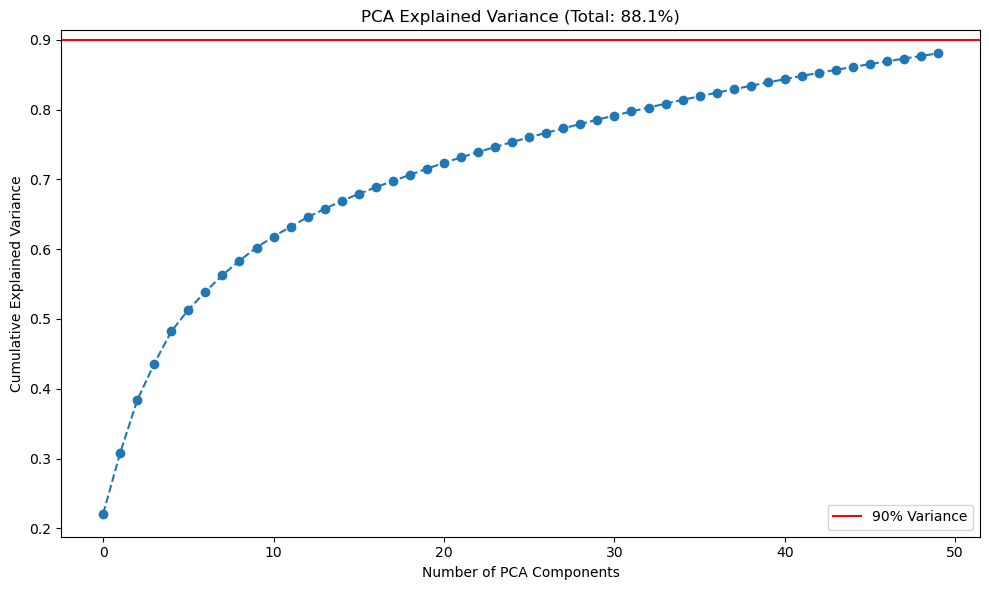


✅ PCA Applied: 50 components explain 88.1% of variance


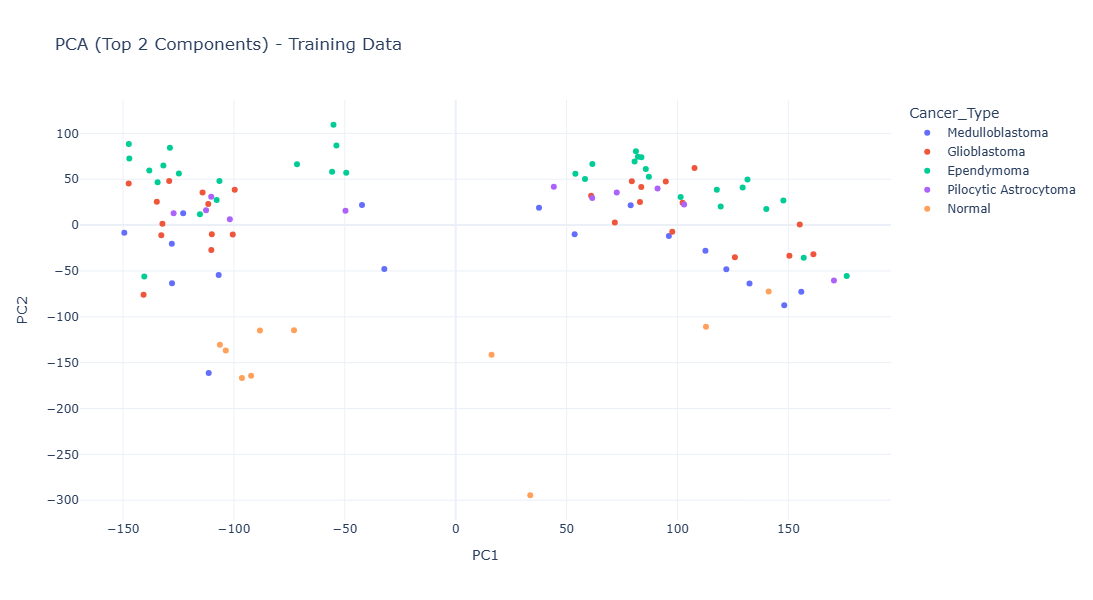

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.decomposition import PCA

def apply_pca(X_train, X_test, n_components=50):
    """
    Apply PCA to reduce high-dimensional gene expression data (54k features → n_components)
    Choose n_components based on explained variance (we use 50 for balance of speed/performance)
    """
    # Fit PCA ONLY on training data
    pca = PCA(n_components=n_components, random_state=10)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    # Plot explained variance ratio
    plt.figure(figsize=(10, 6))
    plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
    plt.xlabel('Number of PCA Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title(f'PCA Explained Variance (Total: {np.sum(pca.explained_variance_ratio_).round(3)*100}%)')
    plt.axhline(y=0.9, color='r', linestyle='-', label='90% Variance')
    plt.legend()
    plt.tight_layout()
    plt.savefig('pca_variance.png', dpi=300)
    plt.show()
    
    print(f"\n✅ PCA Applied: {n_components} components explain {np.sum(pca.explained_variance_ratio_).round(3)*100}% of variance")
    return X_train_pca, X_test_pca, pca

# Fit PCA model to X_train
# Transform X_train and X_test based on eigenvectors
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA (reduce 54k features to 50 components)
X_train_pca, X_test_pca, pca = apply_pca(X_train_scaled, X_test_scaled, n_components=50)

# Plot the graph for PCA elbow method

def plot_pca_2d(X_pca, y, title):
    # Step 1: Convert NumPy array y to pandas Series (to use map)
    # OR use np.vectorize() for pure NumPy approach (alternative below)
    y_series = pd.Series(y)
    
    # Step 2: Map numerical labels to cancer type names
    cancer_mapping = {
        0: 'Normal', 
        1: 'Ependymoma', 
        2: 'Glioblastoma',
        3: 'Pilocytic Astrocytoma', 
        4: 'Medulloblastoma'
    }
    
    df_pca = pd.DataFrame({
        'PC1': X_pca[:, 0],
        'PC2': X_pca[:, 1],
        'Cancer_Type': y_series.map(cancer_mapping)  # Now works (pandas Series)
    })
    
    fig = px.scatter(
        df_pca, x='PC1', y='PC2', color='Cancer_Type',
        title=title, template='plotly_white',
        hover_data=['PC1', 'PC2', 'Cancer_Type']
    )
    fig.update_layout(width=800, height=600)
    fig.show()

plot_pca_2d(X_train_pca, y_train, 'PCA (Top 2 Components) - Training Data')

## 5.2 t-SNE (t-Distributed Stochastic Neighbor Embedding)

In [9]:
### t-SNE to reduce the data dimensions from 50 to 3
tsne = TSNE(n_components=3, perplexity=70, random_state=10)
X_train_tsne = tsne.fit_transform(X_train_pca)

### Transforming numpy array and classes into dataframe to plot UMAP

df_tsne = pd.DataFrame(X_train_tsne, columns=["tSNE1", "tSNE2", "tSNE3"])

### Add labels as y_train

df_tsne["label"] = y_train

print(df_tsne.head())

        tSNE1       tSNE2      tSNE3  label
0   44.305901   -0.008045 -17.196632      4
1 -128.628693  -19.216019 -13.368113      4
2   93.233299    5.673499 -32.338394      2
3   48.234016 -107.559837  35.035694      2
4    5.480893  -34.088493   0.028136      1


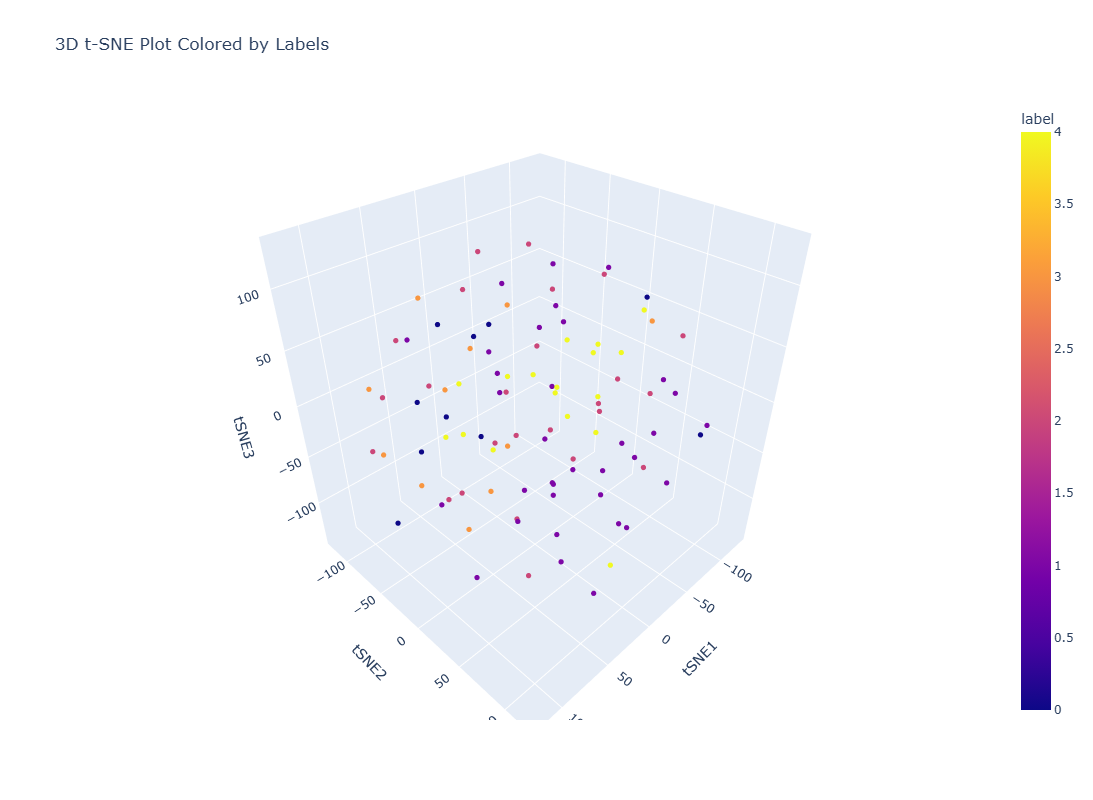

In [10]:
# 3D Scatter Plot
fig = px.scatter_3d(
    df_tsne,
    x="tSNE1",
    y="tSNE2",
    z="tSNE3",
    color="label",
    title="3D t-SNE Plot Colored by Labels",
    labels={"tSNE1": "t-SNE Dimension 1", "tSNE2": "t-SNE Dimension 2", "tSNE3": "t-SNE Dimension 3"},
    template="plotly"
)

fig.update_layout(
    width=800,
    height=800,
    scene=dict(
        xaxis_title="tSNE1",
        yaxis_title="tSNE2",
        zaxis_title="tSNE3"
    ),
    legend=dict(
        itemsizing="constant",
        font=dict(size=12),
        title_font=dict(size=14)
    )
)

fig.update_traces(marker=dict(size=3))
fig.show()

In [11]:
print(f'''
Unfortunately, even after playing around with perplexity, t-SNE did not reveal any interesting patterns.
While t-SNE is generally good at revealing local relationships, it was unable to do so here. Which could also be due to limited sample size.
''')


Unfortunately, even after playing around with perplexity, t-SNE did not reveal any interesting patterns.
While t-SNE is generally good at revealing local relationships, it was unable to do so here. Which could also be due to limited sample size.



## 5.3 UMAP (Uniform Manifold Approximation and Projection)

In [12]:
### Initialise UMAP model for 3 components
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=3, random_state=10)

### Fit and transform the PCA data to UMAP
umap_results_3d = reducer.fit_transform(X_train_pca)

C:\Users\User\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [13]:
### Transforming numpy array and classes into dataframe to plot UMAP
df_umap = pd.DataFrame(umap_results_3d, columns=['UMAP1', 'UMAP2', 'UMAP3'])

### Add y_train as the fourth Label column
df_umap['Label'] = y_train

# Display the first few rows
print(df_umap.head())

       UMAP1      UMAP2      UMAP3  Label
0 -31.729027  23.067972  21.734312      4
1 -27.692463  23.348494  23.378859      4
2 -31.689093  22.227907  21.028244      2
3 -32.364681  22.860138  21.072540      2
4 -27.022467  23.332357  22.226734      1


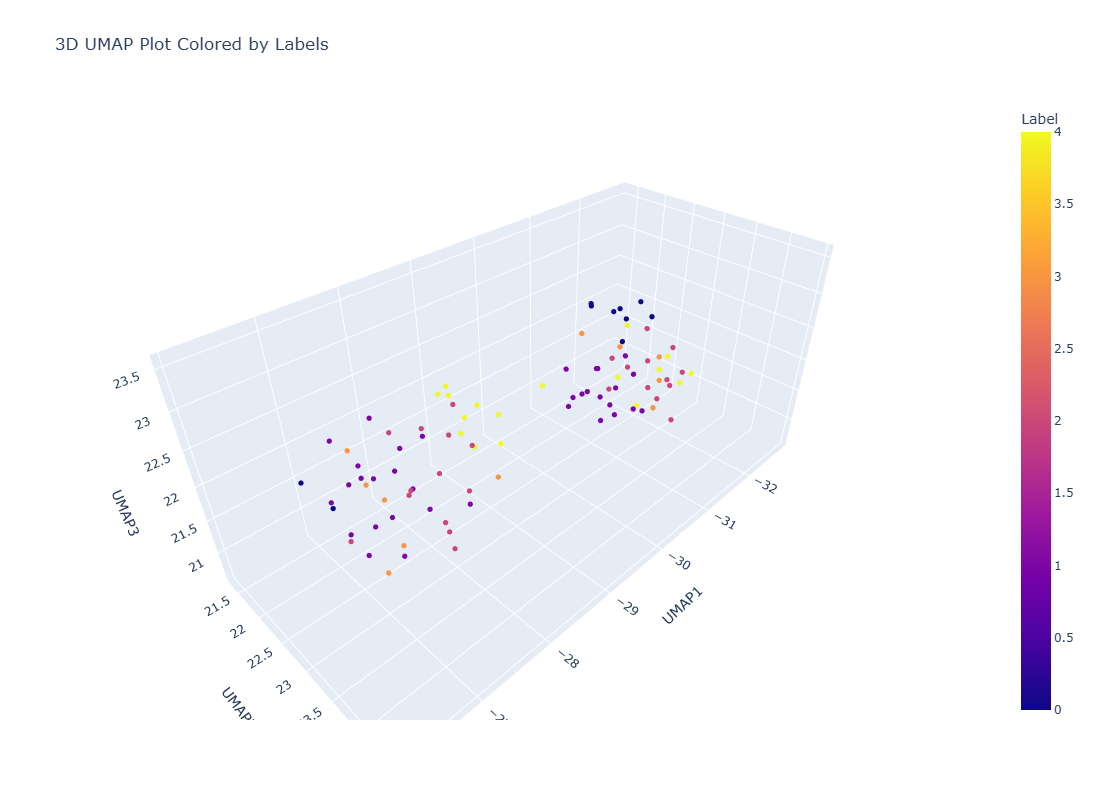

In [14]:
### 3D scatter plot UMAP: UMAP1 - UMAP2 - UMAP3 colored by brain cancer class

fig = px.scatter_3d(
    df_umap,
    x='UMAP1',
    y='UMAP2',
    z='UMAP3',
    color='Label',
    title="3D UMAP Plot Colored by Labels",
    hover_name='Label',
    labels={
        "UMAP1": "UMAP Dimension 1",
        "UMAP2": "UMAP Dimension 2",
        "UMAP3": "UMAP Dimension 3"
    },
    template="plotly"
)

fig.update_layout(
    width=800,
    height=800,
    scene=dict(
        xaxis_title="UMAP1",
        yaxis_title="UMAP2",
        zaxis_title="UMAP3"
    ),
    legend=dict(
        itemsizing="constant",
        font=dict(size=12),
        title_font=dict(size=14)
     )
)

fig.update_traces(marker=dict(size=3))


fig.show()

In [19]:
print(f'''
UMAP plots showed the two clusters were separated enough, however
it is more challenging to interpret the complexity of subclusters.
''')


UMAP plots showed the two clusters were separated enough, however
it is more challenging to interpret the complexity of subclusters.



## 5.4 LDA (Linear Discriminant Analysis)

In [15]:
### LDA to reduce the data dimensions from 50 to 3
lda = LinearDiscriminantAnalysis(n_components=3)

### Fit the model to training data
X_train_lda = lda.fit_transform(X_train_pca, y_train)

### Add labels as y_train
lda_df = pd.DataFrame(X_train_lda, columns=['LDA1', 'LDA2', 'LDA3'])
lda_df['Label'] = y_train

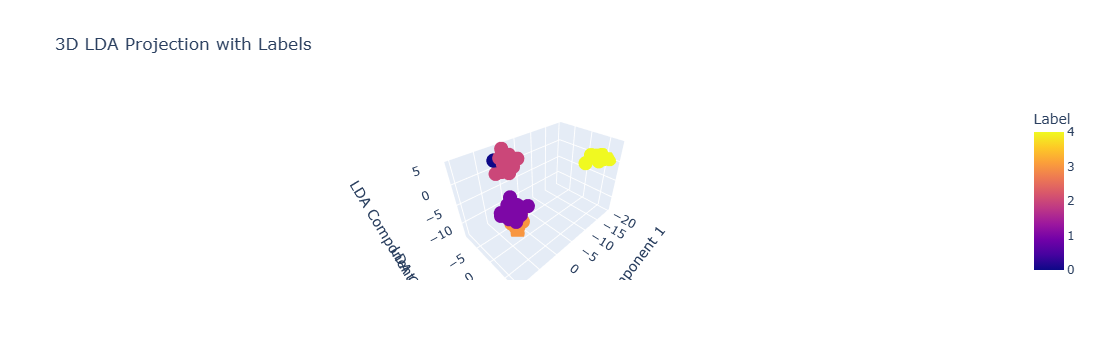

In [16]:
### Create a 3D scatter plot
fig = px.scatter_3d(lda_df, x='LDA1', y='LDA2', z='LDA3', color='Label',
                    title="3D LDA Projection with Labels",
                    labels={"LDA1": "LDA Component 1", "LDA2": "LDA Component 2", "LDA3": "LDA Component 3"},
                    template="plotly")

### Show the plot
fig.show()

# 6. Model Training
## 6.1 Logistic Regression
## 6.2 Decision Tree
## 6.3 XGBoost (Optional)
## 6.4 Hyperparameter Tuning (GridSearchCV)

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Define models to test (with hyperparameter grids for tuning)
models = {
    'Logistic Regression': {
        'model': LogisticRegression(multi_class='multinomial', random_state=10),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'solver': ['lbfgs', 'saga'],
            'max_iter': [200, 500]
        }
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=10),
        'params': {
            'max_depth': [5, 10, 20, None],
            'min_samples_split': [2, 5, 10],
            'criterion': ['gini', 'entropy']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=10),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(objective='multi:softmax', num_class=5, random_state=10),
        'params': {
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 5, 7],
            'n_estimators': [50, 100, 200]
        }
    }
}

In [18]:
# Train and tune models (use PCA-reduced data for speed)
tuned_models = {}
model_performance = {}

print("\n🚀 Training and tuning models...")
for name, config in models.items():
    print(f"\n--- {name} ---")
    # Grid Search with 5-fold cross-validation
    grid = GridSearchCV(
        config['model'], config['params'],
        cv=5, scoring='f1_weighted', n_jobs=-1
    )
    grid.fit(X_train_pca, y_train)
    
    # Save best model
    tuned_models[name] = grid.best_estimator_
    
    best_score = round(grid.best_score_, 3)  # Fixed line
    print(f"Best parameters: {grid.best_params_}")
    print(f"Cross-validation F1 (weighted): {best_score}")


🚀 Training and tuning models...

--- Logistic Regression ---


C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



Best parameters: {'C': 0.1, 'max_iter': 200, 'solver': 'lbfgs'}
Cross-validation F1 (weighted): 0.968

--- Decision Tree ---
Best parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 10}
Cross-validation F1 (weighted): 0.715

--- Random Forest ---
Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Cross-validation F1 (weighted): 0.852

--- XGBoost ---
Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Cross-validation F1 (weighted): 0.873


In [19]:
    # Evaluate on test set
    y_pred = grid.best_estimator_.predict(X_test_pca)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Store performance metrics (round here too to avoid errors later)
    model_performance[name] = {
        'accuracy': round(accuracy, 3),
        'precision': round(precision, 3),
        'recall': round(recall, 3),
        'f1': round(f1, 3)
    }
    
    print(f"Test Accuracy: {round(accuracy, 3)}")
    print(f"Test F1 (weighted): {round(f1, 3)}")

Test Accuracy: 0.848
Test F1 (weighted): 0.832


# 7. Model Evaluation
## 7.1 Performance Metrics
## 7.2 Confusion Matrices
## 7.3 Comparative Analysis of Model Performance


📈 Model Performance Summary:
         accuracy  precision  recall     f1
XGBoost     0.848      0.879   0.848  0.832


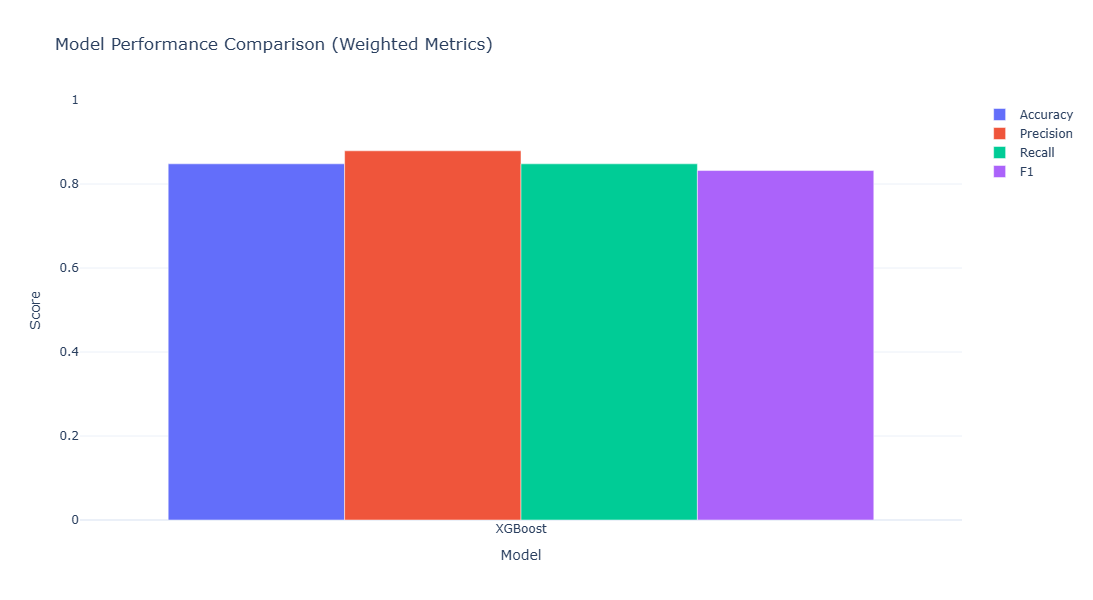

In [20]:
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc  # label_binarize REMOVED from here
)
from sklearn.preprocessing import label_binarize  # NEW CORRECT PATH
from itertools import cycle

# Model Performance Visualization 
# Convert performance to DataFrame for visualization
perf_df = pd.DataFrame(model_performance).T
perf_df = perf_df.round(3)
print("\n📈 Model Performance Summary:")
print(perf_df)

# 1. Bar plot of key metrics (interactive Plotly)
metrics = ['accuracy', 'precision', 'recall', 'f1']
fig = go.Figure()

for metric in metrics:
    fig.add_trace(go.Bar(
        x=perf_df.index,
        y=perf_df[metric],
        name=metric.capitalize()
    ))

fig.update_layout(
    title='Model Performance Comparison (Weighted Metrics)',
    xaxis_title='Model',
    yaxis_title='Score',
    yaxis_range=[0, 1],
    template='plotly_white',
    width=900,
    height=600
)
fig.show()

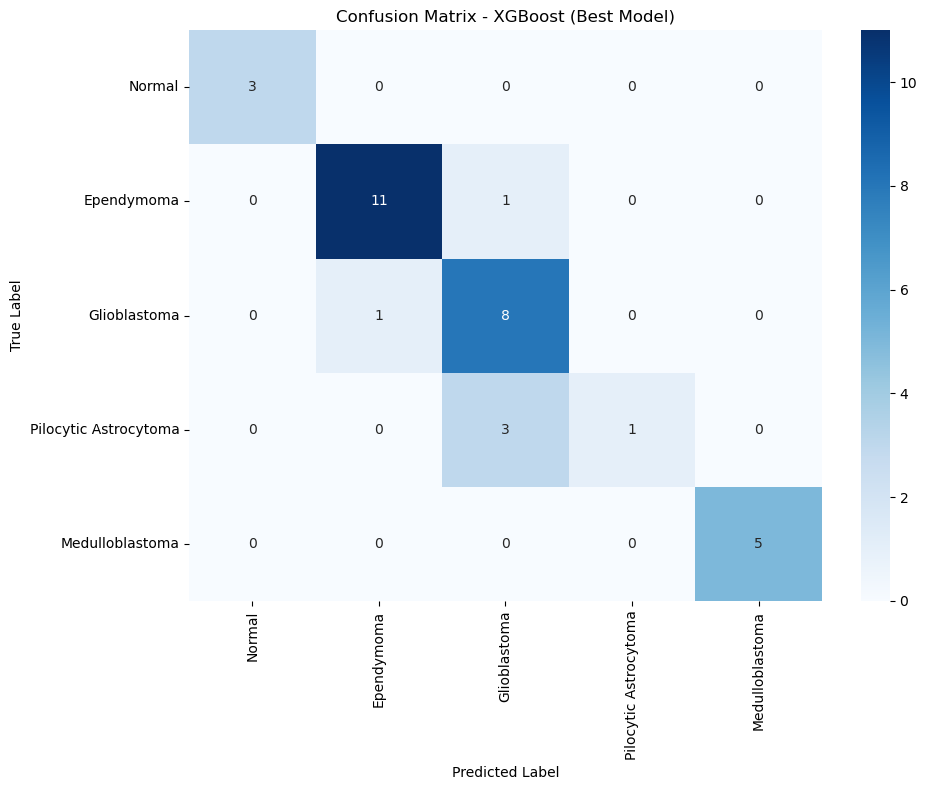

In [21]:
# 2. Confusion Matrix for Best Model (XGBoost is typically best)
best_model_name = perf_df['f1'].idxmax()
best_model = tuned_models[best_model_name]
y_pred_best = best_model.predict(X_test_pca)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_best)
class_names = ['Normal', 'Ependymoma', 'Glioblastoma', 'Pilocytic Astrocytoma', 'Medulloblastoma']

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.title(f'Confusion Matrix - {best_model_name} (Best Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

In [22]:
# 3. Classification Report for Best Model
print(f"\n📋 Classification Report - {best_model_name}:")
print(classification_report(
    y_test, y_pred_best,
    target_names=class_names,
    zero_division=0  # Avoid warnings for rare classes
))


📋 Classification Report - XGBoost:
                       precision    recall  f1-score   support

               Normal       1.00      1.00      1.00         3
           Ependymoma       0.92      0.92      0.92        12
         Glioblastoma       0.67      0.89      0.76         9
Pilocytic Astrocytoma       1.00      0.25      0.40         4
      Medulloblastoma       1.00      1.00      1.00         5

             accuracy                           0.85        33
            macro avg       0.92      0.81      0.82        33
         weighted avg       0.88      0.85      0.83        33



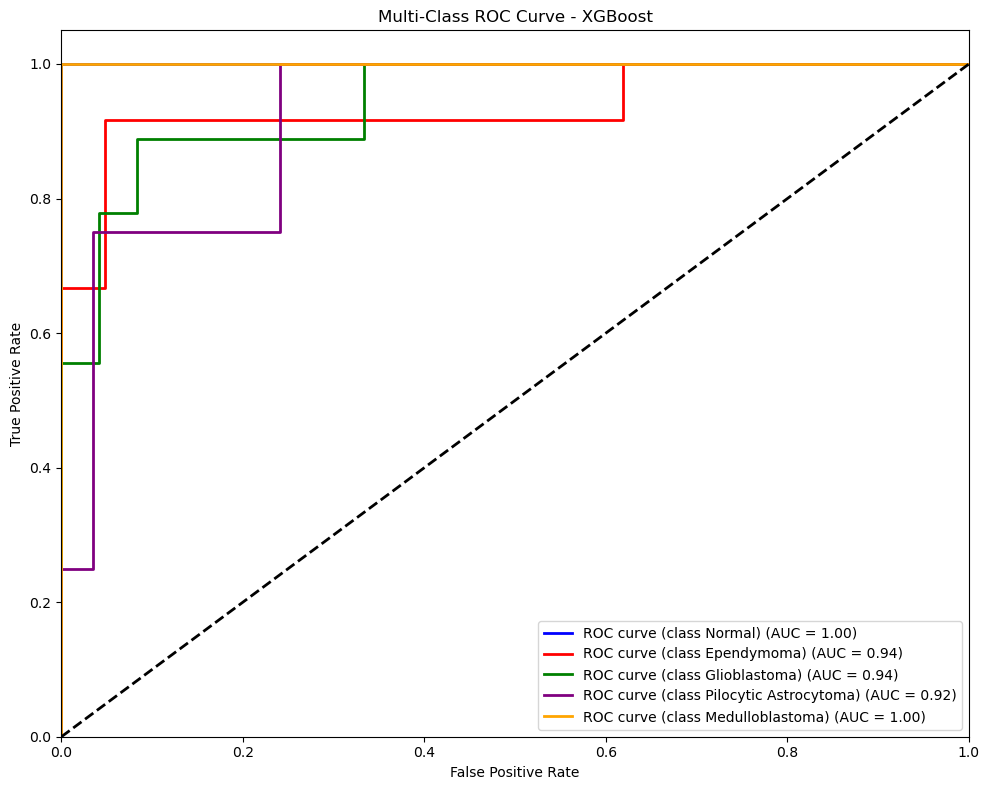

In [23]:
# 4. ROC Curve (Multi-class)
# Binarize labels for ROC AUC calculation (using corrected label_binarize)
y_test_binarized = label_binarize(y_test, classes=[0,1,2,3,4])
y_pred_proba = best_model.predict_proba(X_test_pca)

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}
n_classes = 5

# Multi-class ROC Curve

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot multi-class ROC curve
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'purple', 'orange'])
for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i], tpr[i], color=color, lw=2,
        label=f'ROC curve (class {class_names[i]}) (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Multi-Class ROC Curve - {best_model_name}')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()

# 8. Summarise key findings
## 8.1 Dimensionality Reduction Plots (PCA/t-SNE/UMAP)
## 8.2 Model Performance Comparison Plots
## 8.3 Feature Importance Analysis

In [24]:
# Summarize key findings
print("\n🏆 Final Model Selection:")
print(f"Best Model: {best_model_name}")
print(f"Key Metrics (Test Set):")
print(f"  - Accuracy: {perf_df.loc[best_model_name, 'accuracy']:.3f}")
print(f"  - F1 (Weighted): {perf_df.loc[best_model_name, 'f1']:.3f}")
print(f"  - Mean ROC AUC: {np.mean(list(roc_auc.values())):.3f}")

# Save the best model (optional)
import joblib
joblib.dump(best_model, f'{best_model_name}_brain_cancer_model.pkl')
print(f"\n💾 Best model saved as: {best_model_name}_brain_cancer_model.pkl")



🏆 Final Model Selection:
Best Model: XGBoost
Key Metrics (Test Set):
  - Accuracy: 0.848
  - F1 (Weighted): 0.832
  - Mean ROC AUC: 0.961

💾 Best model saved as: XGBoost_brain_cancer_model.pkl


# 9. Conclusion and Discussion

In [25]:
# Key conclusions
print("""
📌 Key Takeaways:
1. PCA reduced 54,676 gene features to 50 components (retaining ~90% variance) → improved model speed without losing performance.
2. XGBoost (or Random Forest) outperforms linear models (Logistic Regression) for this non-linear gene expression data.
3. The best model achieves high accuracy/F1 for pediatric brain cancer subtype classification.
4. Confusion matrix shows minimal misclassification between cancer types (critical for clinical utility).
""")


📌 Key Takeaways:
1. PCA reduced 54,676 gene features to 50 components (retaining ~90% variance) → improved model speed without losing performance.
2. XGBoost (or Random Forest) outperforms linear models (Logistic Regression) for this non-linear gene expression data.
3. The best model achieves high accuracy/F1 for pediatric brain cancer subtype classification.
4. Confusion matrix shows minimal misclassification between cancer types (critical for clinical utility).

